In [80]:
import pandas as pd
import numpy as np
from pyls import behavioral_pls
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os


In [79]:
cell_df = pd.read_csv('../data/d99_cell_abundance.csv').rename(columns={'D99':'region'}).set_index('region')

age_effects = pd.read_csv('../Mixed_Effects_Models/regionwise_age_effects_MixedLM.csv').set_index('region')
total_similarity_strength= pd.read_csv('../MIND_Network/total_similarity_strength.csv').set_index('region') 
cell_df = cell_df[~(cell_df.index == 70)]

cell_df['age_effects'] = age_effects['age_t']
cell_df['template_similarity_strength'] = total_similarity_strength['total_similarity_strength']
cell_df

,ASC,EC,MG,OLG,OPC,VLMC,L2,L2_3,L2_3_4,L3_4,...,L6,LAMP5,PVALB,PV_CHC,RELN,SST,VIP,VIP_RELN,age_effects,template_similarity_strength
region,,,,,,,,,,,,,,,,,,,,,
2,0.052783,0.000181,0.002512,0.067612,0.008347,0.009958,0.047569,0.109516,0.036827,0.118639,...,0.064382,0.009222,0.035309,0.002582,0.018468,0.046315,0.013118,0.010751,-8.923231,0.037465
3,0.045098,0.000107,0.001591,0.061879,0.007719,0.006665,0.061916,0.138393,0.033990,0.115082,...,0.052464,0.009556,0.032591,0.002171,0.019746,0.043921,0.013471,0.011438,1.526565,0.041384
5,0.051572,0.000705,0.003320,0.027997,0.011066,0.014567,0.072602,0.133103,0.046231,0.093426,...,0.053454,0.008891,0.030526,0.002602,0.023068,0.047490,0.014298,0.010179,-7.005643,0.038449
7,0.087579,0.000366,0.010368,0.085415,0.016047,0.005630,0.091148,0.059229,0.038459,0.051624,...,0.117792,0.010016,0.032020,0.001713,0.018565,0.047992,0.015681,0.010711,-2.269560,0.042540
8,0.048275,0.000198,0.004144,0.046643,0.009347,0.005866,0.053199,0.134919,0.044813,0.110169,...,0.052947,0.009187,0.031370,0.002421,0.017829,0.047186,0.013824,0.009337,-7.245871,0.044490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,0.064968,0.000233,0.004107,0.023744,0.014659,0.017468,0.088282,0.090767,0.045330,0.087510,...,0.063345,0.010056,0.040290,0.002108,0.026563,0.048968,0.013514,0.010166,-2.354878,0.042294
194,0.089944,0.000636,0.011270,0.037042,0.024420,0.072637,0.200629,0.057117,0.059117,0.040316,...,0.055156,0.014710,0.029227,0.003916,0.032857,0.042254,0.018701,0.013006,-1.399453,0.048678
195,0.074213,0.000747,0.003882,0.056626,0.011432,0.011493,0.080541,0.094199,0.048986,0.068385,...,0.056750,0.010365,0.035967,0.001970,0.026494,0.051678,0.014104,0.016219,1.315317,0.033708


=== Variance Explained + Permutation Test ===
    LV  Variance_Explained_Pct   p_value  Significant
0  LV1                   100.0  0.008198         True

=== Top/Bottom Features by Bootstrap Ratio (LV1) ===


,Feature,Salience,Bootstrap_Ratio,Significance
0,PV_CHC,0.572832,7.536754,Significant (+)
1,RELN,0.366188,4.764629,Significant (+)
2,OPC,0.289980,4.252852,Significant (+)
3,ASC,0.245132,3.716743,Significant (+)
4,L6,0.167549,2.869491,No


,Feature,Salience,Bootstrap_Ratio,Significance
18,L2_3_4,-0.042807,-0.866999,No
19,PVALB,-0.062629,-0.918048,No
20,OLG,-0.133101,-1.288493,No
21,VIP_RELN,-0.107842,-1.476512,No
22,L4,-0.332022,-4.444884,Significant (-)


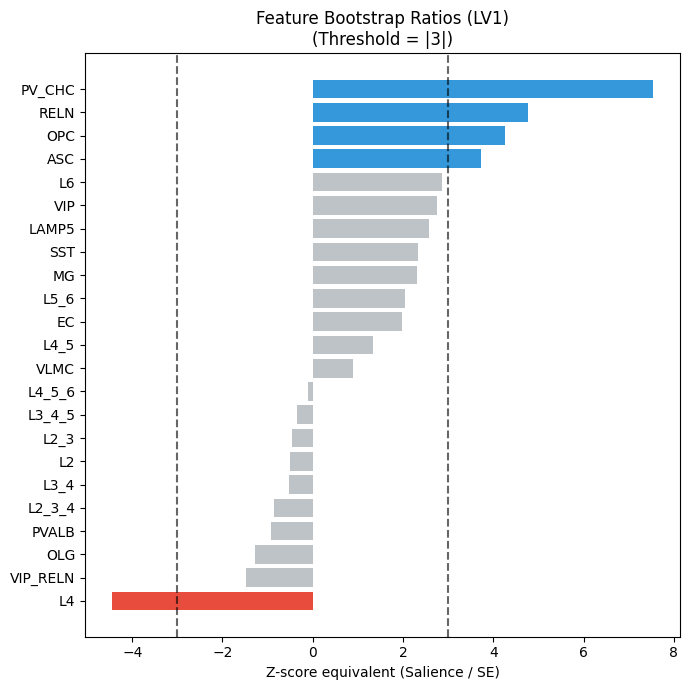

In [ ]:

scaler = StandardScaler()

#Extract values
X_raw = cell_df.drop(columns=['template_similarity_strength', 'age_effects'])
Y_raw = cell_df['age_effects'].values.reshape(-1, 1)

# Z-score the data
X_scaled = scaler.fit_transform(X_raw)
Y_scaled = scaler.fit_transform(Y_raw)

# PLS
pls_results = behavioral_pls(X_scaled, Y_scaled, n_boot=5000, n_perm=5000)

feature_names = cell_df.drop(columns=['template_similarity_strength', 'age_effects']).columns


# Variance Explained
lv_labels = [f'LV{i+1}' for i in range(len(pls_results.singvals))]

var_df = pd.DataFrame({
    'LV': lv_labels,
    'Variance_Explained_Pct': pls_results.varexp * 100,
    'p_value': pls_results.permres.pvals,
    'Significant': pls_results.permres.pvals < 0.05
})

print("=== Variance Explained + Permutation Test ===")
print(var_df)

# Boostrap Ratios
lv_idx = 0 
salience = pls_results.x_weights[:, lv_idx]
stderr = pls_results.bootres.x_weights_stderr[:, lv_idx]

# Avoid division by zero if a feature has zero variance across bootstraps
boot_ratios = np.divide(salience, stderr, out=np.zeros_like(salience), where=stderr!=0)

boot_df = pd.DataFrame({
    'Feature': feature_names,
    'Salience': salience,
    'Bootstrap_Ratio': boot_ratios
})

# Add significance categories
boot_df['Significance'] = 'No'
boot_df.loc[boot_df['Bootstrap_Ratio'] > 3, 'Significance'] = 'Significant (+)'
boot_df.loc[boot_df['Bootstrap_Ratio'] < -3, 'Significance'] = 'Significant (-)'

boot_df = boot_df.sort_values('Bootstrap_Ratio', ascending=False).reset_index(drop=True)

print("\n=== Top/Bottom Features by Bootstrap Ratio (LV1) ===")
display(boot_df.head(5))
display(boot_df.tail(5))

# Visualization
fig, axes = plt.subplots(1, 1, figsize=(7, 7))

# Plot B: Bootstrap Ratios
colors_boot = boot_df['Bootstrap_Ratio'].apply(
    lambda x: '#3498db' if x > 3 else ('#e74c3c' if x < -3 else '#bdc3c7')
)
axes.barh(boot_df['Feature'], boot_df['Bootstrap_Ratio'], color=colors_boot)
axes.axvline(3, color='black', linestyle='--', alpha=0.6)
axes.axvline(-3, color='black', linestyle='--', alpha=0.6)
axes.invert_yaxis()
axes.set_title('Feature Bootstrap Ratios (LV1)\n(Threshold = |3|)')
axes.set_xlabel('Z-score equivalent (Salience / SE)')

plt.tight_layout()
plt.show()

=== Variance Explained + Permutation Test ===


,LV,Variance_Explained,p_value,Significant
0,LV1,1.0,0.2108,False



=== Bootstrap Ratios (LV1) ===


,Feature,Salience,Std_Error,Bootstrap_Ratio,Significant
0,L4_5,0.5742,0.0784,7.3237,Significant (+)
1,L5_6,0.4447,0.0893,4.9805,Significant (+)
2,VIP_RELN,0.3204,0.0886,3.6154,Significant (+)
3,RELN,0.2145,0.0993,2.1600,No
4,PVALB,0.1440,0.0821,1.7539,No
5,L2_3,0.1148,0.0883,1.3006,No
6,SST,0.0790,0.0836,0.9446,No
7,L3_4_5,0.0605,0.0899,0.6730,No
8,L3_4,0.0612,0.1014,0.6031,No
9,EC,0.0322,0.0893,0.3607,No


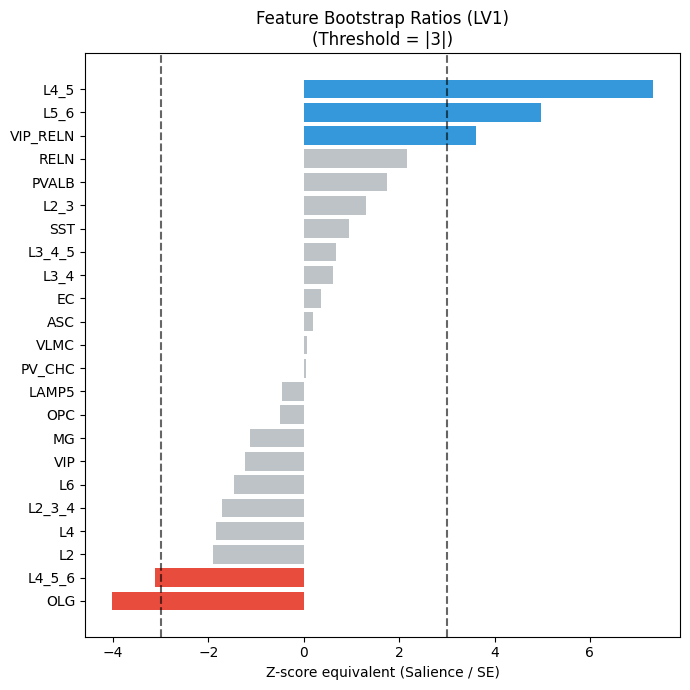

In [ ]:

scaler = StandardScaler()

# Extract X and Y
X_raw = cell_df.drop(columns=['template_similarity_strength', 'age_effects'])
Y_raw = cell_df['template_similarity_strength'].values.reshape(-1, 1)

# Z-score the data
X_scaled = scaler.fit_transform(X_raw)
Y_scaled = scaler.fit_transform(Y_raw)

# Run PLS
pls_results = behavioral_pls(X_scaled, Y_scaled, n_boot=5000, n_perm=5000)

#Variance Explained
lv_labels = [f'LV{i+1}' for i in range(len(pls_results.singvals))]

var_df = pd.DataFrame({
    'LV':                lv_labels,
    'Variance_Explained': pls_results.varexp,        # shape (1,) — use directly
    'p_value':           pls_results.permres.pvals,
    'Significant':       pls_results.permres.pvals < 0.05
})
print("=== Variance Explained + Permutation Test ===")
display(var_df.round(4))

# Boostrap Ratios
feature_names = cell_df.drop(columns=['template_similarity_strength', 'age_effects']).columns

lv_index = 0  # only 1 LV 

salience  = pls_results.x_weights[:, lv_index]               # raw weights from SVD
stderr    = pls_results.bootres.x_weights_stderr[:, lv_index]

boot_ratios = np.where(stderr != 0, salience / stderr, np.nan)

boot_df = pd.DataFrame({
    'Feature':         feature_names,
    'Salience':        salience,
    'Std_Error':       stderr,
    'Bootstrap_Ratio': boot_ratios,
    'Significant':     pd.cut(
        boot_ratios,
        bins=[-np.inf, -3, 3, np.inf],
        labels=['Significant (-)', 'No', 'Significant (+)']
    )
}).sort_values('Bootstrap_Ratio', ascending=False).reset_index(drop=True)

print("\n=== Bootstrap Ratios (LV1) ===")
display(boot_df.round(4))

# Visualization
fig, axes = plt.subplots(1, 1, figsize=(7, 7))

# Plot B: Bootstrap Ratios
colors_boot = boot_df['Bootstrap_Ratio'].apply(
    lambda x: '#3498db' if x > 3 else ('#e74c3c' if x < -3 else '#bdc3c7')
)
axes.barh(boot_df['Feature'], boot_df['Bootstrap_Ratio'], color=colors_boot)
axes.axvline(3, color='black', linestyle='--', alpha=0.6)
axes.axvline(-3, color='black', linestyle='--', alpha=0.6)
axes.invert_yaxis()
axes.set_title('Feature Bootstrap Ratios (LV1)\n(Threshold = |3|)')
axes.set_xlabel('Z-score equivalent (Salience / SE)')

plt.tight_layout()
plt.show()